In [33]:
# Capstone -- function 8 (8D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.spatial import ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 8

8D — the highest-dimensional function in the set. Unit cube `[0,1]^8`. 44 observations (40 initial + weeks 2–5), all in-domain and all in the fit. Acquisition: **`ucb`, `kappa = 0.5`**, over seven live axes {x0–x6}; x7 held at the incumbent.

## Progress

| week | y | note |
|---|---|---|
| 2 | 9.927989 | |
| 3 | 9.802053 | dip |
| 4 | 9.945552 | |
| 5 | **9.948250** | confound test (x4→1.0); new incumbent |

(Week 2's value was once queried as a possible `29.93` typo — settled as `9.93`; weeks 3–5 sit in the same band.)

## Week 5 resolved the x4 confound

Weeks 2–4 held x4 and x7 at the incumbent, and all three collected points sat at the same x4 = 0.586936 — the GP couldn't separate x4's effect from anything else those points shared. Its pinned length-scale (10.0) fitted a ramp through the cluster and extrapolated it, claiming a 28× larger gain (+0.179 vs +0.006) from moving x4 to 1.0, while the raw data (Spearman ≈ −0.06 to −0.12) pointed the other way.

**The test:** move x4 to 1.0, nothing else. Result: `y = 9.948250`, barely above the prior incumbent (9.945552) — nowhere near the GP's predicted +10.12. **H2 confirmed: the ramp was a confound artefact**, not a real effect.

**Consequence: x4 comes off the held list.** With two distinct x4 values now, its length-scale unpins (10.0 → 7.41) and its mean-variation (0.262, 12% of the top axis) clears the flat threshold. x7 is still frozen at one value and still pinned — it stays held, untested.

**Consequence: `kappa` moves 0.25 → 0.5.** Same predicted-gain criterion, now with x4 live: `kappa=1.0` loses to the incumbent and lands on x0/x2's lower bound; `0.5` is the largest value that still gains and touches no bound. This is the first week in three where the proposal is the acquisition's actual output, not a diagnostic.

## What 8D breaks

- **Convex hull is vacuous.** All 44 observations are hull vertices; the hull is 0.48% of the bounding box. Skipped — per-axis and domain-edge checks carry the weight instead.
- **`compute_iteration_diagnostics` needs `domain_grid_n = 4`** — the default 40 would need a `40**8` (6.6e12-point) grid.

## Notes

- **No y-scaling.** `y` spans 5.6–9.95; `xi=0.01` is 0.23% of the spread, and `kappa` is dimensionless regardless.
- **EI/PI**: both are now live dials at every `xi` tested (previously EI looked fully degenerate) — both still collapse to the same variance-seeking point at large `xi`. Neither claim depends on the now-resolved x4 question.
- **Best-calibrated model in the set.** LOO: 42/44 inside their own 95% interval; worst-predicted is an ordinary initial point (−1.7σ), not the incumbent or a collected point.
- x7 remains confounded; freeing it only claims +0.001 more gain than holding it, not worth a week yet.

In [34]:
X_initial = np.load("initial_data/function_8/initial_inputs.npy")
y_initial = np.load("initial_data/function_8/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 8, f"Expected an 8D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week.

In [35]:
# My collected observations, from weekly_data/function_8/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance, oldest first:
#   - week 2 -- y = 9.927989 (settled: not a 29.93 typo -- weeks 3-5 sit in
#       the same band).
#   - week 3 -- x1/x3/x6 landed on the 0.0 floor; y dipped to 9.802053.
#   - week 4 -- y = 9.945552, incumbent until week 5.
#   - week 5 -- confound test: x4 moved to 1.0, else unchanged from the
#       week-4 incumbent. y = 9.948250, a marginal +0.0027 -- confirms the
#       x4 "ramp" was a confound artefact, not a real effect. New incumbent.

new_X, new_y, pending_X = load_collected(8, D)

# Label each row by its own week and read the direction off the data. This used
# to print new_y[-1] as "week 3" and then assert "week 3 is slightly BELOW week
# 2" -- both wrong once there were three rows, and the second contradicted the
# change it had just printed.
print("observations collected so far:", len(new_y))
_running = y_initial.max()
for r, v in enumerate(new_y):
    tag = "   <- a new best" if v > _running else ""
    print("  week %d y: %.6f%s" % (r + 2, v, tag))
    _running = max(_running, v)
print("best on record: %.6f (the initial batch alone reached %.6f)"
      % (max(y_initial.max(), new_y.max()), y_initial.max()))
_dip = int(np.argmin(new_y))
print("-> week %d was the dip (%.6f): three coordinates were driven to the 0.0"
      % (_dip + 2, new_y[_dip]))
print("   floor and the response did not improve, so that direction is spent.")


weekly store: 4 resulted observation(s), 1 pending proposal [0.122451 0.182741 0.121434 0.154182 0.811786 0.473842 0.224237 0.603135]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 4
  week 2 y: 9.927989   <- a new best
  week 3 y: 9.802053
  week 4 y: 9.945552   <- a new best
  week 5 y: 9.948250   <- a new best
best on record: 9.948250 (the initial batch alone reached 9.598482)
-> week 3 was the dip (9.802053): three coordinates were driven to the 0.0
   floor and the response did not improve, so that direction is spent.


## Build the full dataset (initial + everything collected so far)

In [36]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.6f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# The domain is the unit cube, so bounds are [0,1] on every axis. BOTH edges are
# real domain constraints now -- the upper one used to be pad_fraction padding,
# and the checks below no longer treat the two differently.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
# Bounds ARE the domain, so an observation could legitimately sit outside them
# (earlier weeks proposed points above 1 before the domain was known). Validate
# the in-domain subset and report any others rather than dying on them. No
# observation is currently outside, so this is future-proofing.
_in_dom = np.all((X >= bounds[:, 0]) & (X <= bounds[:, 1]), axis=1)
validate_bounds_consistency(X[_in_dom], bounds)
if not _in_dom.all():
    print(f"\n{int((~_in_dom).sum())} observation(s) OUTSIDE the [0,1] domain:")
    for i in np.flatnonzero(~_in_dom):
        over = [f"x{d}={X[i, d]:.4f}" for d in range(D) if X[i, d] > 1.0]
        print(f"  {', '.join(over)}   y={y[i]:+.5g}")
    print("  Kept in the fit unless they distort it -- measure before excluding.")
print("\nBounds (upper):", np.round(bounds[:, 1], 4))

# The 0.0 floor is a real domain constraint, so a coordinate sitting exactly
# on it is legitimate -- but it also means the axis has run out of room in
# that direction, which is worth seeing per week.
print("\ncollected points vs the INITIAL batch's range:")
for r in range(len(new_X)):
    n_out = n_floor = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        n_floor += new_X[r, d] == 0.0
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}{'  <- on the 0.0 floor' if new_X[r, d] == 0.0 else ''}")
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates outside,"
          f" {n_floor} on the 0.0 floor, y={new_y[r]:.6f}")

# At D=8 the convex hull is vacuous: with this few points there is essentially
# no interior, so every proposal reads as outside it. Quantified rather than
# assumed. Delaunay is skipped -- expensive and uninformative at this D.
try:
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.2%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices")
    if len(ch.vertices) == len(X):
        print("-> EVERY point is a vertex: the hull has no interior, so a")
        print("   hull-membership test carries no information at this D.")
except Exception as exc:
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (40, 8) | combined X shape: (44, 8)
y range: 5.592193 to 9.948250 (spread 4.356057, std 1.084751)

Bounds (upper): [1. 1. 1. 1. 1. 1. 1. 1.]

collected points vs the INITIAL batch's range:
  week 2  x0=0.095333  initial range [0.0091, 0.9859]  outside=False
  week 2  x1=0.261314  initial range [0.0034, 0.9740]  outside=False
  week 2  x2=0.113603  initial range [0.0229, 0.9989]  outside=False
  week 2  x3=0.282728  initial range [0.0090, 0.9030]  outside=False
  week 2  x4=0.586936  initial range [0.0096, 0.9869]  outside=False
  week 2  x5=0.541680  initial range [0.0221, 0.9902]  outside=False
  week 2  x6=0.291424  initial range [0.0359, 0.9929]  outside=False
  week 2  x7=0.603135  initial range [0.0420, 0.9888]  outside=False
  -> week 2: 0 of 8 coordinates outside, 0 on the 0.0 floor, y=9.927989
  week 3  x0=0.035759  initial range [0.0091, 0.9859]  outside=False
  week 3  x1=0.000000  initial range [0.0034, 0.9740]  outside=True  <- on the 0.0 floor
  week 3  x2

## Is the model stable and calibrated?

Refit on the initial batch alone, predict the four collected points out-of-sample: all land within 1.3σ (largest miss: week 2, 1.21σ). Then compare kernels before/after: x3 unpins most (9.84 → 4.94, ~50%, the largest move but still under the instability threshold); x4 also unpins (10.0 → 7.41) now that it's no longer frozen. x7 stays pinned before and after — the stability that licenses continuing to hold it.

In [37]:
# Both fits first, in one block, so no ConvergenceWarning can land between the
# rows printed below. Two separate blocks here printed two identical reports.
with fitting("before/after fits for the collected observations"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is genuinely out of
# sample. The model that actually proposed week 3 also had week 2, so for the
# later rows this understates what was known at proposal time.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.6f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))
print("ratio (after/before):", np.round(ls_after / ls_before, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

# Printed to 1dp rather than 0dp: the largest move here rounds to "50%" while
# sitting just under the 50% threshold, which made the display look at odds with
# the guard not firing.
moved = float(np.max(np.abs(ls_after / ls_before - 1)))
_which = int(np.argmax(np.abs(ls_after / ls_before - 1)))
print(f"\nlargest relative length-scale change: {moved:.1%} (on x{_which},"
      f" {ls_before[_which]:.2f} -> {ls_after[_which]:.2f})")
if moved > 0.5:
    print("*** A length-scale moved by more than 50% across the collected")
    print("    observations. Which direction matters: an axis becoming MORE relevant")
    print("    (length-scale SHRINKING) is benign; the dangerous case is a blow-up")
    print("    that inflates far-field variance. ***")
elif ls_after[_which] < ls_before[_which]:
    print("  -> it SHRANK, i.e. that axis now looks more relevant. Benign.")


[fitting: before/after fits for the collected observations] 5 warnings held back, 3 distinct:
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted +9.823401 +/- 0.086719   actual +9.927989
    miss +0.104588 = +1.2 sigma  -> well calibrated
  week 3: predicted +10.026082 +/- 0.230693   actual +9.802053
    miss -0.224029 = -1.0 sigma  -> well calibrated
  week 4: predicted +9.870108 +/- 0.121067   actual +9.945552
    miss +0.075444 = +0.6 sigma  -> well calibrated
  week 5: predicted +10.053884 +/- 0.156206   actual +9.948250
    miss -0.105634 = -0.7 sigma  -> well calibrated

kernel before: 3.7**2 * Matern(length_scale=[3.14, 4.39, 2.26, 9.84, 10, 4.48, 3.12, 10], nu=2.5) + WhiteKernel(noise_leve

## Which axes matter

Flat if mean-variation < 5% of the largest axis, or length-scale ≥ 9.0. Now that x4 is unfrozen, only **x7** is flat — pinned length-scale (10.0) and negligible mean-variation (3% of x2's). The GP and Spearman rank agree on direction for every other axis; they disagree only on x7, which is frozen, so its GP direction isn't evidence either way.

In [38]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 6))
print("y = %.6f" % y.max())

print("\n%3s | %17s | %15s | %10s | %9s | %s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman", "rank agree?"))
spans = np.zeros(D)       # mean-variation over the full domain
spans_obs = np.zeros(D)   # ... and over the observed range only
srs = np.zeros(D)
for d in range(D):
    for col, (lo, hi) in enumerate([(bounds[d, 0], bounds[d, 1]),
                                    (X[:, d].min(), X[:, d].max())]):
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        (spans if col == 0 else spans_obs)[d] = m.max() - m.min()
    srs[d] = spearmanr(X[:, d], y)[0]

rank_span = np.argsort(np.argsort(-spans))
rank_sr = np.argsort(np.argsort(-np.abs(srs)))
for d in range(D):
    agree = "yes" if abs(int(rank_span[d]) - int(rank_sr[d])) <= 1 else "no"
    # The observed-range figure was being computed and then thrown away: this
    # column printed `0.0 if d < 0 else spans[d]`, and d < 0 is never true, so
    # it duplicated the full-domain number in every row.
    print("%3d | %17.4g | %15.4g | %10.3f | %+9.3f | %s (%d vs %d)"
          % (d, spans[d], spans_obs[d], ls_after[d], srs[d],
             agree, rank_span[d] + 1, rank_sr[d] + 1))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
for d in flat:
    why = []
    if spans[d] < FLAT_FRAC * spans.max():
        why.append("low mean-variation")
    if ls_after[d] >= 0.9 * PINNED:
        why.append(f"length-scale {ls_after[d]:.2f}")
    print(f"  x{d}: {', '.join(why)}")
print("axes searched:", live)

# A monotone axis whose best end is a domain bound will put the proposal ON that
# bound -- expected, not a defect. And an axis frozen at one value across every
# collected point cannot have its effect separated from those points' other
# features: the GP will happily fit a ramp through them. Flag both here.
for d in range(D):
    if abs(srs[d]) > 0.4:
        which = "LOWER" if srs[d] < 0 else "UPPER"
        print(f"  x{d} is monotone (spearman {srs[d]:+.3f}): best end is the {which}"
              " domain bound, so a proposal sitting there is expected")

for d in range(D):
    vals = np.unique(np.round(new_X[:, d], 9))
    if len(new_X) > 1 and len(vals) == 1:
        print(f"  *** x{d} is FROZEN at {vals[0]:.6f} across all {len(new_X)} collected"
              " points.")
        print(f"      Its effect cannot be separated from whatever else those points"
              " share, so")
        print(f"      the GP's direction on x{d} (spearman {srs[d]:+.3f})"
              " is confounded. See the header. ***")
order = np.argsort(spans)[::-1]
print("dominance: x%d is only %.1fx the next (x%d) -> no single dominant axis"
      % (order[0], spans[order[0]] / spans[order[1]], order[1]))

incumbent (best observed): [0.106878 0.190311 0.050599 0.209113 1.       0.414903 0.21378  0.603135]
y = 9.948250

 ax | GP mean-variation |  same, observed |  len-scale |  spearman | rank agree?
  0 |             1.517 |           1.472 |      3.428 |    -0.687 | yes (2 vs 1)
  1 |            0.5468 |          0.5132 |      5.163 |    -0.350 | yes (4 vs 4)
  2 |             2.197 |           2.192 |      2.860 |    -0.669 | yes (1 vs 2)
  3 |            0.5397 |          0.4206 |      4.942 |    -0.226 | yes (5 vs 5)
  4 |             0.262 |          0.2559 |      7.406 |    +0.011 | no (6 vs 8)
  5 |            0.1665 |          0.1605 |      5.777 |    +0.021 | yes (7 vs 7)
  6 |             1.145 |           1.125 |      3.439 |    -0.438 | yes (3 vs 3)
  7 |           0.06323 |         0.05544 |     10.000 |    +0.098 | no (8 vs 6)

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): [7]
  x7: low mean-variation, length-scale 10.00
axes searched: [0, 1, 2, 3, 4, 5, 6]

## Backtest acquisition functions (using only data already collected)

Same structural caveat as always: this scores recognition of already-known points, an exploitation task, so it favours `exploit`/low `kappa` regardless of what's appropriate. `exploit` leads on mean regret; `ucb_k0.5` (my committed choice) ranks 3rd, about 2.4 s.e. behind — at the edge of, but outside, "within noise". Read it as a mild caution, not a veto; the live-proposal checks below are what the choice actually rests on.

xi for the PI/EI rows: 0.043561 (1% of the y spread)

[fitting: acquisition backtest, 50 splits] 178 warnings held back, 6 distinct:
    48 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    42 x  ConvergenceWarning  k1__k2__length_scale (dim 5) pinned at upper bound 10.0
    40 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
    31 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
    13 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |      0.03565 |              0 |          9.889
   ucb_k0.25 |       0.0473 |              0 |          9.877
    ucb_k0.5 |      0.05716 |              0 |          9.867
          pi |      0.07185 |              0 

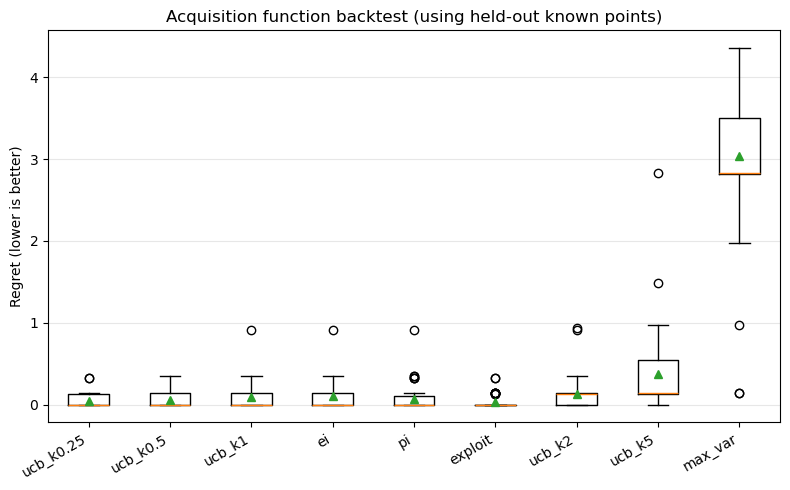

In [39]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.25", "acquisition": "ucb", "kappa": 0.25},
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)\n")

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# Which acquisition looks best so far. Configs are compared PAIRED on the same
# splits, so "within noise" below means |mean difference| <= 2 standard errors --
# plain arithmetic, no statistical test. Read it knowing the metric scores
# RECOGNITION of points whose y is already known, which is an exploitation task.
CHOSEN = "ucb_k0.5"        # must name the committed KAPPA; asserted where KAPPA is set

assert CHOSEN in backtest_results, (
    f"{CHOSEN!r} is not among the backtest configs, so the committed setting is "
    f"never scored. Add a row for it. Have: {sorted(backtest_results)}"
)

names = list(backtest_results)
mean_r = {k: float(backtest_results[k]["regret"].mean()) for k in names}
med_r = {k: float(np.median(backtest_results[k]["regret"])) for k in names}
ranked = sorted(names, key=lambda k: mean_r[k])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [k for k in ranked[1:]
        if abs(paired_gap(leader, k)[0]) <= 2 * paired_gap(leader, k)[1]]
worse = [k for k in ranked[1:] if k not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda k: med_r[k])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for k in ranked[1:]:
    gap, se = paired_gap(leader, k)
    print(f"  {k:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>5.1f} s.e.)"
          f"   {'within noise' if k in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")
print("Do NOT switch on this table alone -- see the bias note above, and check")
print("where each candidate would actually propose before acting on it.")

plot_acquisition_backtest(backtest_results)
plt.show()


## EI and PI

Checked again with the new data. Both move away from their small-`xi` proposal as `xi` grows, and both collapse onto the same variance-seeking point at large `xi` — the mechanism function 4 showed: the improvement term is hopeless everywhere in this 8D box. UCB stays the only family here whose exploration weight I actually control.

In [40]:
spread = y.max() - y.min()

# All five fits happen first, inside one fitting() block, and the rows are built
# but not printed. Printing inside the loop put each fit's ConvergenceWarnings
# between the table rows.
_rows = []
with fitting("EI/PI xi sweep, 5 fits"):
    for acq, xi in [("ei", 0.01 * spread), ("ei", 0.05 * spread), ("ei", 0.25 * spread),
                    ("pi", 0.01 * spread), ("pi", 0.25 * spread)]:
        xn, g = generate_next_point(X, y, bounds, acquisition=acq, xi=xi, maximize=True,
                                    n_restarts=40, random_state=0)
        m, sd = g.predict(normalize(xn.reshape(1, -1), bounds), return_std=True)
        edge = sum(np.isclose(xn[d], bounds[d, 0]) or np.isclose(xn[d], bounds[d, 1])
                   for d in range(D))
        out = sum(not (X[:, d].min() <= xn[d] <= X[:, d].max()) for d in range(D))
        _rows.append((f"{acq} xi={xi:.3f}", m[0], sd[0], edge, out))

print(f"{'config':>16} | {'pred mean':>10} | {'pred std':>9} | on bound | outside obs")
for name, m, sd, edge, out in _rows:
    print(f"{name:>16} | {m:+10.4f} | {sd:9.4f} | {edge:>3}/{D}   | {out}/{D}")

_ei = [m for n, m, *_ in _rows if n.startswith("ei")]
_pi = [m for n, m, *_ in _rows if n.startswith("pi")]
DEGENERATE_TOL = 0.05
print(f"\nincumbent y = {y.max():.4f}")
print(f"EI: predicted mean ranges {min(_ei):+.4f} to {max(_ei):+.4f} across the xi's tested"
      f" -> {'degenerate, same point throughout' if max(_ei) - min(_ei) < DEGENERATE_TOL else 'xi is a live dial'}")
print(f"PI: predicted mean ranges {min(_pi):+.4f} to {max(_pi):+.4f}"
      f" -> {'degenerate, same point throughout' if max(_pi) - min(_pi) < DEGENERATE_TOL else 'xi is a live dial'}")
print("UCB remains the only family here whose exploration weight I can control directly.")

[fitting: EI/PI xi sweep, 5 fits] 10 warnings held back, 2 distinct:
     5 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     5 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
          config |  pred mean |  pred std | on bound | outside obs
     ei xi=0.044 |    +9.8290 |    0.1816 |   2/8   | 2/8
     ei xi=0.218 |    +8.7638 |    0.2968 |   0/8   | 0/8
     ei xi=1.089 |    +8.7638 |    0.2968 |   0/8   | 0/8
     pi xi=0.044 |    +9.9595 |    0.0741 |   0/8   | 0/8
     pi xi=1.089 |    +8.7638 |    0.2968 |   0/8   | 0/8

incumbent y = 9.9483
EI: predicted mean ranges +8.7638 to +9.8290 across the xi's tested -> xi is a live dial
PI: predicted mean ranges +8.7638 to +9.9595 -> xi is a live dial
UCB remains the only family here whose exploration weight I can control directly.


## Comparing kappa before I commit

Unrestricted over all 8 axes, `kappa` 0→5: bound contact climbs from 0/8 to 8/8, and x7 (still pinned) is the first axis to hit an edge.

Restricted to the 7 live axes (x7 held), which is what I make the choice from: **`kappa=0.5` is the largest value whose predicted mean still beats the incumbent** (+0.018), touching no bound. `kappa=1.0` loses (−0.033) and lands on x0/x2's lower edge — corroborated by their negative rank correlations (−0.69, −0.67).

=== unrestricted over all 8 axes (shown to demonstrate the corner problem) ===
[fitting: kappa sweep (one shared GP)] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
 kappa |  pred mean |  on bound |            UPPER bound
     0 |    +9.9730 |       0/8 |                   none
   0.5 |    +9.9570 |       1/8 |                    [7]
     1 |    +9.9307 |       2/8 |                    [7]
     2 |    +9.6143 |       4/8 |                    [5]
     5 |    +9.2548 |       8/8 |              [3, 4, 5]


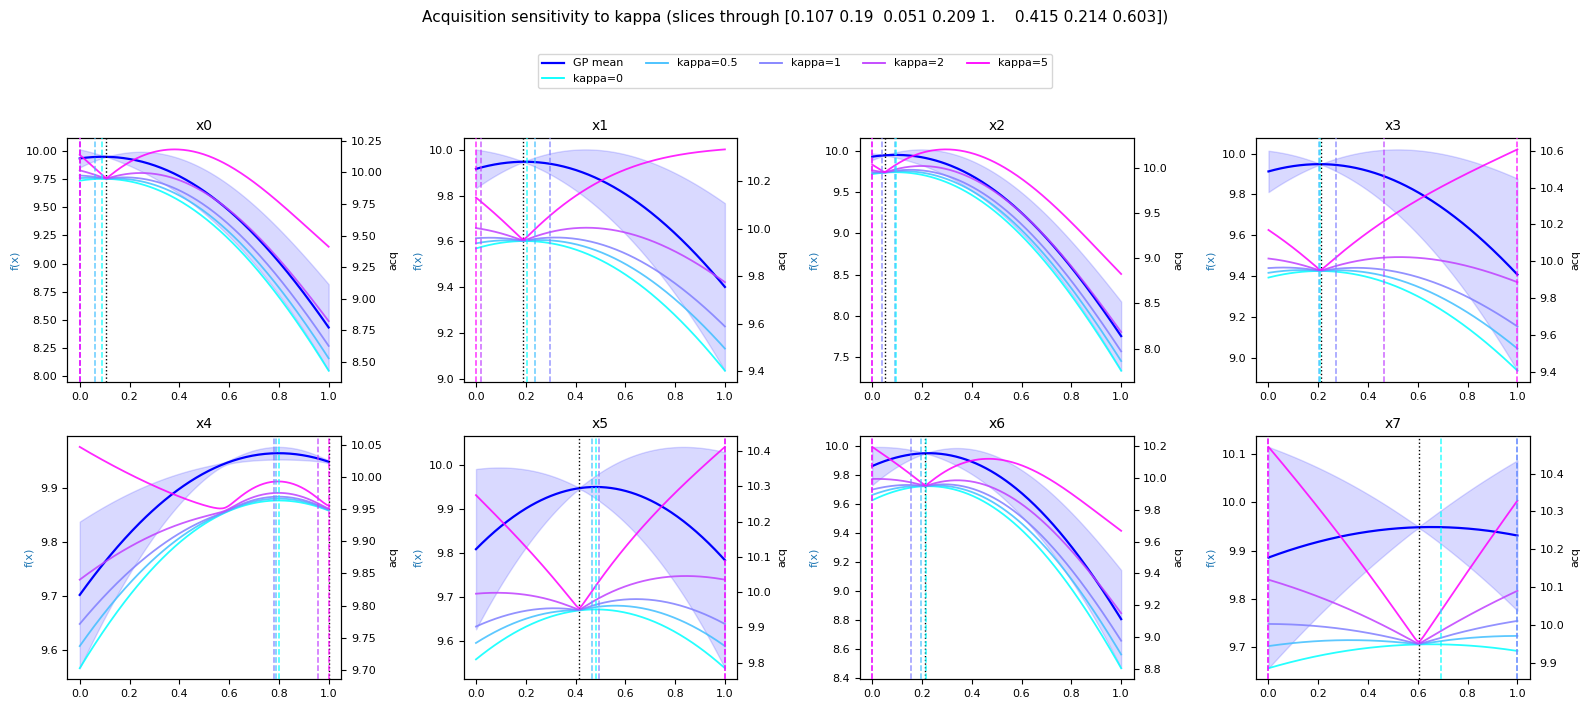


=== restricted to the live axes x[0, 1, 2, 3, 4, 5, 6], holding x[7] at the incumbent ===
 kappa |  pred mean |      gain |  pred std |  UPPER edge |  lower edge |    dist
     0 |    +9.9717 |   +0.0235 |    0.0149 |        none |        none |  0.2136
  0.25 |    +9.9705 |   +0.0223 |    0.0239 |        none |        none |  0.2141
   0.5 |    +9.9664 |   +0.0181 |    0.0349 |        none |        none |  0.2176
     1 |    +9.9151 |   -0.0331 |    0.1009 |        none |      [0, 2] |  0.3547
incumbent y = 9.948250

using kappa = 0.5, searching only x[0, 1, 2, 3, 4, 5, 6]
chosen as the largest kappa whose predicted mean still beats the incumbent:
  kappa=0.0   pred mean +9.971746  gain +0.023496
  kappa=0.25  pred mean +9.970503  gain +0.022253
  kappa=0.5   pred mean +9.966379  gain +0.018129  <- committed
  kappa=1.0   pred mean +9.915133  gain -0.033117


In [41]:
def bound_report(p):
    """Report which coordinates sit on a domain edge, upper and lower separately.

    Bounds are the true domain [0,1], so NEITHER edge is automatically a defect
    -- contact means the constrained optimum is on the boundary, which on a
    monotone axis is exactly right. I judge it per axis against that axis's
    monotone direction (see the axis cell), not by which edge it is.
    """
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print("=== unrestricted over all 8 axes (shown to demonstrate the corner problem) ===")
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.0, 0.5, 1.0, 2.0, 5.0],
                                          maximize=True, n_restarts=40, random_state=0)

print(f"{'kappa':>6} | {'pred mean':>10} | {'on bound':>9} | {'UPPER bound':>22}")
for row in kappa_rows:
    up, lo = bound_report(row["x_next"])
    print(f"{row['kappa']:6g} | {row['pred_mean']:+10.4f} | {len(up) + len(lo):>7}/{D}"
          f" | {str(up) if up else 'none':>22}")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()


def restricted_ucb(kappa, n_starts=100):
    """Maximise UCB over the live axes only, holding flat axes at the incumbent."""
    lo = bounds[live, 0]
    hi = bounds[live, 1]

    def neg(v):
        p = incumbent.copy()
        p[live] = v
        return -ucb_acquisition(normalize(p.reshape(1, -1), bounds), gp_check,
                                 kappa=kappa, maximize=True)[0]

    best_val, best_v = np.inf, None
    rng = np.random.default_rng(0)
    for start in rng.uniform(lo, hi, size=(n_starts, len(live))):
        res = minimize(neg, start, method="L-BFGS-B", bounds=list(zip(lo, hi)))
        if res.fun < best_val:
            best_val, best_v = res.fun, res.x
    p = incumbent.copy()
    p[live] = best_v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    return p, m[0], s[0]


print(f"\n=== restricted to the live axes x{live}, holding x{flat} at the incumbent ===")
# Rows computed once and reused for the criterion below, so the two can't
# disagree and I don't pay for the L-BFGS restarts twice.
_gain_rows = []
for k in [0.0, 0.25, 0.5, 1.0]:
    p, m, s = restricted_ucb(k)
    up, lo_ = bound_report(p)
    _gain_rows.append((k, m, s, up, lo_, float(np.linalg.norm(p - incumbent))))

print(f"{'kappa':>6} | {'pred mean':>10} | {'gain':>9} | {'pred std':>9}"
      f" | {'UPPER edge':>11} | {'lower edge':>11} | {'dist':>7}")
for k, m, s, up, lo_, dist in _gain_rows:
    print(f"{k:6g} | {m:+10.4f} | {m - y.max():+9.4f} | {s:9.4f}"
          f" | {str(up) if up else 'none':>11} | {str(lo_) if lo_ else 'none':>11}"
          f" | {dist:7.4f}")
print(f"incumbent y = {y.max():.6f}")

# My choice, defined here so the proposal, the slice plot and the diagnostics
# replay all read one value and can't drift apart.
#
# Chosen as the largest kappa whose predicted mean still BEATS the incumbent.
KAPPA = 0.5
print(f"\nusing kappa = {KAPPA}, searching only x{live}")
print("chosen as the largest kappa whose predicted mean still beats the incumbent:")
for k, m, *_ in _gain_rows:
    mark = "  <- committed" if k == KAPPA else ""
    print(f"  kappa={k:<5} pred mean {m:+.6f}  gain {m - y.max():+.6f}{mark}")

# The verdict cell above reports how the committed setting ranks, which only
# means something if CHOSEN names this KAPPA. Config names follow
# f"ucb_k{kappa:g}", so this is checkable rather than a comment to remember.
_expected = f"ucb_k{KAPPA:g}"
assert CHOSEN == _expected, (
    f"CHOSEN={CHOSEN!r} does not match the committed KAPPA={KAPPA}"
    f" (expected {_expected!r}). The backtest verdict above refers to a config"
    " this notebook does not use -- fix one or the other."
)


## Propose the next point

Restricted UCB over the 7 live axes at `kappa=0.5`, x7 held at the incumbent. Convex hull is skipped (vacuous at this D, see above); the per-axis range and domain-edge checks carry the weight instead.

In [42]:
gp = gp_check
x_next, mu_next, sigma_next = restricted_ucb(KAPPA, n_starts=200)

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu_next:.6f}, predicted std: {sigma_next:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu_next - y.max():+.6f}")
print(f"flat axes x{flat} held at the incumbent:"
      f" {np.allclose(x_next[flat], incumbent[flat])}")

# Bounds are the TRUE DOMAIN, so neither edge is automatically a defect. The
# question is whether the axis is monotone toward that edge (expected) or not.
up, lo = bound_report(x_next)
for label, dims, is_upper in (("UPPER", up, True), ("lower", lo, False)):
    print(f"\non the {label} domain edge:", dims or "none")
    for d in dims:
        sr = float(srs[d])
        if abs(sr) > 0.4 and ((sr > 0) == is_upper):
            print(f"  x{d}: EXPECTED -- monotone (spearman {sr:+.3f}) with its best end here")
        else:
            print(f"  x{d}: QUESTION IT -- spearman {sr:+.3f} does not point this way")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\noutside the observed range on its own axis:", outside or "none")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}")

--- Next point to evaluate (bounds shape (8, 2)) ---
x_next: [0.122451 0.182741 0.121434 0.154182 0.811786 0.473842 0.224237 0.603135]
3.72**2 * Matern(length_scale=[3.43, 5.16, 2.86, 4.94, 7.41, 5.78, 3.44, 10], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 9.966379, predicted std: 0.034937
current best observed y: 9.948250  -> predicted improvement: +0.018129
flat axes x[7] held at the incumbent: True

on the UPPER domain edge: none

on the lower domain edge: none

outside the observed range on its own axis: none

distance from the incumbent: 0.217583
nearest 3 observations to x_next:
  dist=0.2176  y=+9.948250
  dist=0.2500  y=+9.945552
  dist=0.2884  y=+9.927989


## Visualise the GP and acquisition function via 1D slices

Eight panels, each holding the other seven dimensions at the incumbent and sweeping one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

Expect **x7 flat** (span 3% of x2's) and **x4 showing a modest slope** (span 12% of x2's) — no longer pinned, but still one of the less sensitive axes. x0, x2 and x6 should dominate.

A partial view only: eight 1D slices through one point say nothing about interactions, which at D=8 is most of the space.

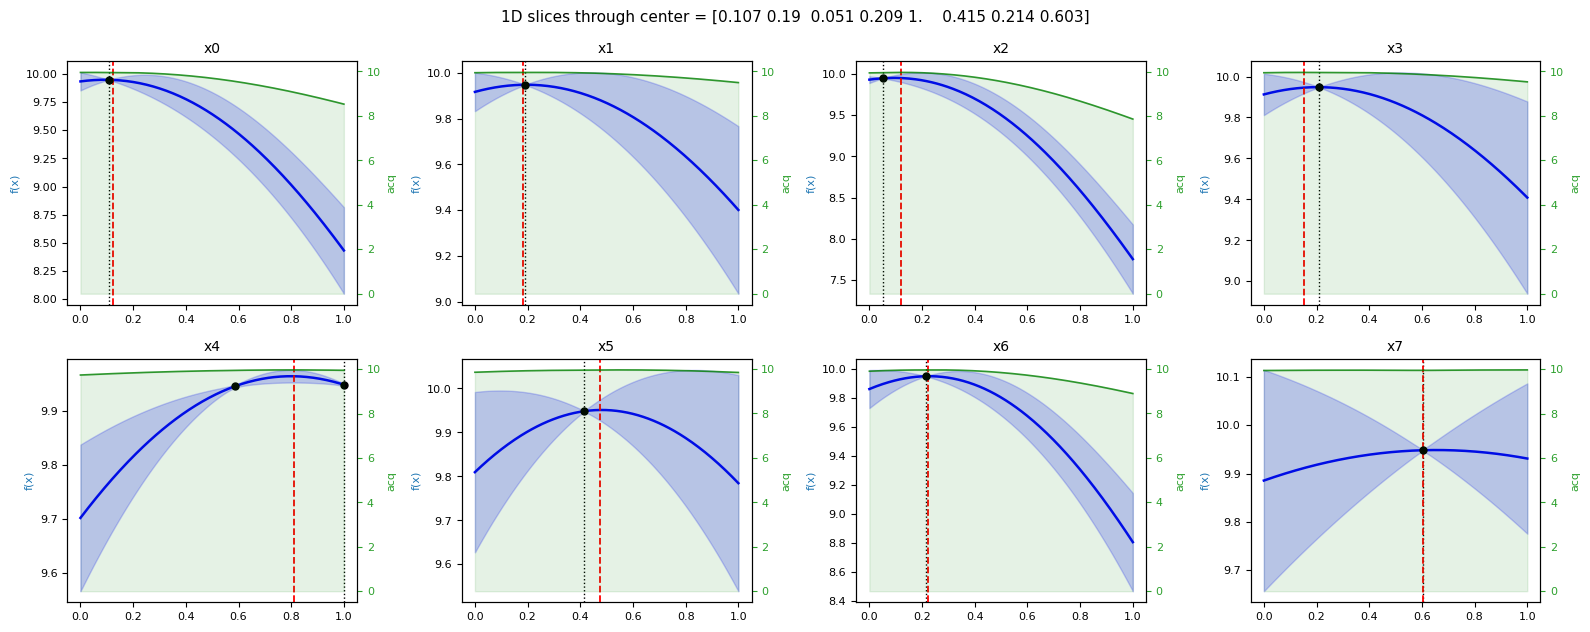

In [43]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refits once per observation, holding it out and predicting it from the rest. 42 of 44 points land inside their own 95% interval; worst-predicted is an ordinary initial observation, not the incumbent or one of the collected points.

`random_state` is pinned: `gp_kwargs` is forwarded to `fit_gp` on every refit, so this cell would not otherwise be reproducible run to run.

[fitting: leave-one-out calibration] 90 warnings held back, 4 distinct:
    44 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
    44 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 5) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0


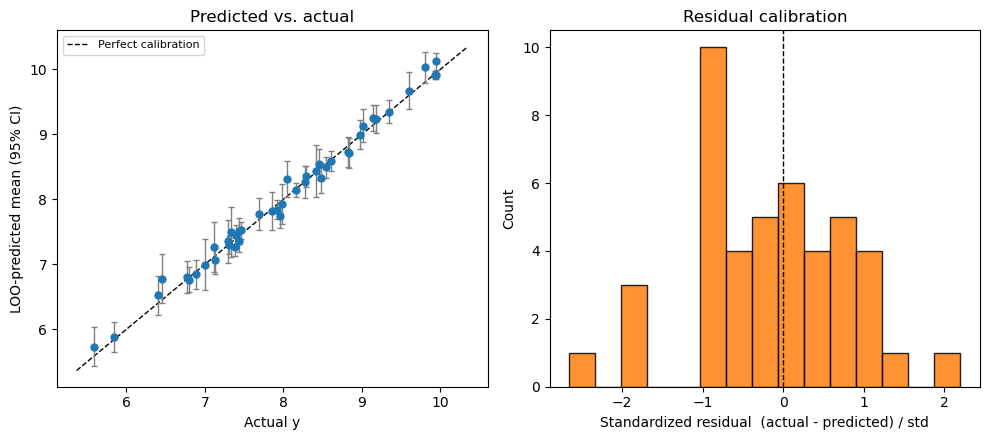

points inside their own 95% LOO interval: 42/44
worst-predicted: index 24 -> true 6.451943, predicted 6.779508 (std 0.193555) = -1.7 sigma
  that point comes from the initial batch
is it the incumbent? False


In [44]:
# random_state is pinned: gp_kwargs goes to fit_gp on every one of the 43
# refits, so unseeded this cell was not reproducible run to run -- and the
# markdown states which point is worst-predicted, so that has to be stable.
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(
        X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20, "random_state": 0})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})"
      f" = {(y[worst] - pred_mean[worst]) / pred_std[worst]:+.1f} sigma")
src = ("the initial batch" if worst < n_initial
       else f"collected week {worst - n_initial + 2}")
print(f"  that point comes from {src}")
print("is it the incumbent?", worst == int(np.argmax(y)))


## Iteration diagnostics

Replays the ordered `X`/`y` to reconstruct acquisition value, GP hyperparameters and domain-wide uncertainty at each past proposal. No persisted log involved.

**`domain_grid_n` has to come down drastically at D=8** — the default 40 would need a `40**8 = 6.6e12`-point grid (~419,000 GB). Sized instead to keep the grid near 200,000 points, giving `domain_grid_n = 4`. `domain_mean_std` is then a coarse estimate, comparable across iterations within this notebook only.

Caveat: the four collected rows were not all proposed under one acquisition/`kappa`, and the replay applies one setting throughout, so `acq_value` is an artefact of that mismatch, not a property of any point. The GP-hyperparameter and `domain_mean_std` columns don't depend on the acquisition and are fine throughout.

`plot_bo_diagnostics` is skipped (hard-codes a 2D scatter panel); the trend plots below are dimension-agnostic and gated on at least three completed iterations.

domain_grid_n = 4 -> 65,536 grid points (the default 40 would be 6,553,600,000,000)
domain_mean_std is therefore very coarse: comparable across iterations
within this notebook, not across notebooks or grid sizes.
[fitting: iteration-diagnostics replay] 12 warnings held back, 3 distinct:
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
     4 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     4 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06

Best y so far: 9.9482502473075

CAVEAT: my history is MIXED -- the 4 collected rows were not all
proposed under ucb/kappa=0.5, and compute_iteration_diagnostics applies one
setting across the whole replay. So acq_value is an artefact of that mismatch
rather than a property of any point. The GP-hyperparameter and domain_mean_std
columns don't depend on the acquisition and are fine throughout.
completed iterations in the modelling set: 4


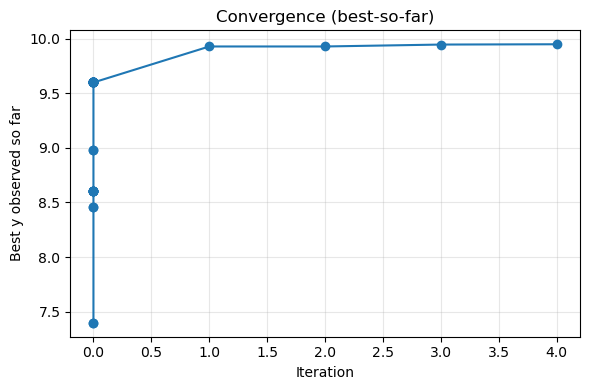

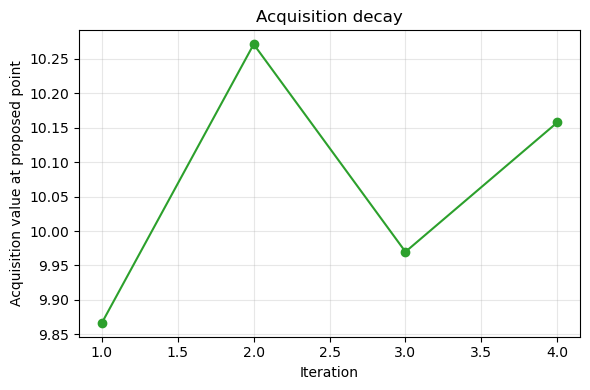

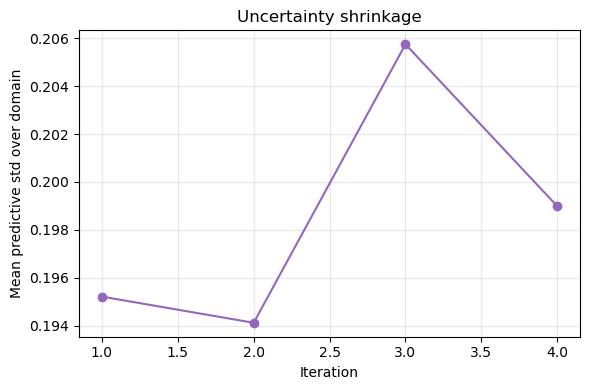

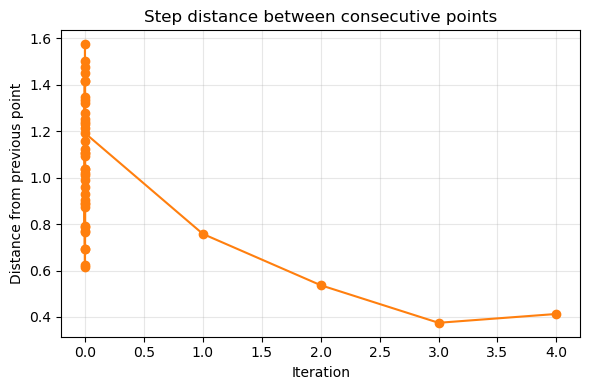

In [45]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default 40
# is 40**8 = 6.6e12 points (~419,000 GB) at D=8. Size it so the grid stays near
# 200k points whatever D is -- here that means just 4 samples per axis.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")
print("domain_mean_std is therefore very coarse: comparable across iterations")
print("within this notebook, not across notebooks or grid sizes.")

# The count comes from the MODELLING set rather than len(new_y), so it stays
# correct if I ever exclude rows from the fit.
n_replayed = len(y) - n_initial

with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True,
                                            domain_grid_n=DOMAIN_GRID_N)

print("\nBest y so far:", np.nanmax(history["y"]))
print(f"\nCAVEAT: my history is MIXED -- the {n_replayed} collected rows were not all")
print(f"proposed under ucb/kappa={KAPPA}, and compute_iteration_diagnostics applies one")
print("setting across the whole replay. So acq_value is an artefact of that mismatch")
print("rather than a property of any point. The GP-hyperparameter and domain_mean_std")
print("columns don't depend on the acquisition and are fine throughout.")
print("completed iterations in the modelling set:", n_replayed)

if n_replayed >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before the")
    print("trend plots say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [46]:
print("y (last 5):", np.round(history["y"][-5:], 5))
print("iteration (last 5):", history["iteration"][-5:])
obs = ~np.isnan(history["acq_value"])
print("\nfor the proposed (non-initial) points only:")
print("  acq_value      :", history["acq_value"][obs])
print("  pred_mean      :", history["pred_mean"][obs])
print("  actual y       :", history["y"][obs])
print("  length_scale   :", history["length_scale"][obs])
print("  domain_mean_std:", history["domain_mean_std"][obs])

y (last 5): [9.18301 9.92799 9.80205 9.94555 9.94825]
iteration (last 5): [0. 1. 2. 3. 4.]

for the proposed (non-initial) points only:
  acq_value      : [ 9.86676102 10.27116578  9.96982603 10.15761328]
  pred_mean      : [ 9.82340143 10.17155214  9.95245143 10.12447833]
  actual y       : [9.92798929 9.80205265 9.94555211 9.94825025]
  length_scale   : [5.90482995 5.81579586 5.41507289 5.48713062]
  domain_mean_std: [0.1952088  0.19411379 0.20575536 0.19898716]


In [47]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.122451-0.182741-0.121434-0.154182-0.811786-0.473842-0.224237-0.603135

full precision (use for next week's new_X):
0.12245053045004668-0.18274129084242718-0.12143352884212676-0.15418237882069774-0.8117857173552967-0.4738422797493823-0.2242373842310192-0.603135


In [48]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(8, new_X, x_next)


wrote weekly_data/function_8/inputs.csv: 5 row(s) (4 resulted + 1 proposal)
  proposal row: 0.12245053045004668-0.18274129084242718-0.12143352884212676-0.15418237882069774-0.8117857173552967-0.4738422797493823-0.2242373842310192-0.603135


'weekly_data/function_8/inputs.csv'